In [82]:
import sys
import os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..', '..'))
sys.path.append(parent_dir)

In [83]:
import tslearn.metrics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['font.size'] = 18 #14  Default font size for text elements
plt.rcParams['axes.labelsize'] = 18 #16 # Font size for x and y labels
plt.rcParams['axes.titlesize'] = 18 #20 # Font size for the title
plt.rcParams['xtick.labelsize'] = 14 #12 # Font size for x-axis tick labels
plt.rcParams['ytick.labelsize'] = 14 #12 # Font size for y-axis tick labels
plt.rcParams['legend.fontsize'] = 16 #14 # Font size for the legend
plt.rcParams['figure.titlesize'] = 22 #22 # Font size for the figure's suptitle

import torch
from torch.utils.data import DataLoader, TensorDataset

from models.transformer_encoder import TransEncoder
#from models.transformer_encoder_x_attn import TransEncoder
#from models.transformer_encoder_new import TransEncoder_2 as TransEncoder

from ddpm.transformer_ddpm import GaussianDiffusion1D

from models.oneD_unet_cond import Unet
from ddpm.OneD_ddpm import DDPM

from models.baseline import BaselineDenoisingNetwork
from ddpm.baseline_ddpm import DDPM as DDPM_base

from torch.optim import Adam

seed = 42

np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

In [84]:
## Data
seq_len = 336
batch_size = 128

#NN
device = 'cuda' if torch.cuda.is_available() else 'cpu'
latent_dim = 256
cond_model = "mlp"
num_layers = 6
n_heads = 8
lr = 1e-4
betas = (0.9, 0.99)
epochs = 5000
save_rate = 50

## DDPM
timesteps = 1000
beta_schedule = "cosine"
objective = "pred_noise"

#RQ3
weather = True
stats = False

## Logging
experiment = f"tstr_mae{seq_len}"
model_name = "trans"
experiment_name = f"{model_name}_humidity_temp"
logging_dir = f"{experiment}/{experiment_name}/"
weights_dir = "../../logging/rq3_336/temperature_humid_features/weights/best_model.pth"

In [85]:
# latent_dim = 1000
# cond_model = "mlp"
# n_heads = 4
# lr = 5*16**-4
# decay_rate = 0.9

In [86]:
if not os.path.isdir(f"../../logging/eval/{logging_dir}"):
    os.makedirs(f"../../logging/eval/{logging_dir}")

In [87]:
viz_dir= f"../../logging/eval/{logging_dir}"

In [88]:
PREPROCESSED_DIR = "../../preprocessing/data/customer_led_network_revolution/preprocessed/"

In [89]:
def time_weather_fe(df, seq_len, weather_data, weather=False, stats=False):
    num_meters = df.shape[0]
    features = 4
    if weather:
        features += weather_data.shape[0]

    if stats:
        features += 6

    conditioning_data = np.zeros((num_meters, features, seq_len))

    dates = df.iloc[:, :seq_len].columns
    for idx, date in enumerate(dates):
        hour = pd.to_datetime(date).hour
        day = pd.to_datetime(date).day
        minute = pd.to_datetime(date).minute
        is_weekend = int(day in [5, 6])
        
        day = np.sin(2 * np.pi * day / 7)
        hour = np.sin(2 * np.pi * hour / 24)
        minute = np.sin(2 * np.pi * minute / 60)
        
        conditioning_data[:, 0, idx] = minute
        conditioning_data[:, 1, idx] = hour
        conditioning_data[:, 2, idx] = day
        conditioning_data[:, 3, idx] = is_weekend
        
        if weather:
            conditioning_data[:, 4:18, idx] = weather_data.iloc[:, idx]
        
    if stats:
        means = df.iloc[:, :seq_len].mean()
        stds =  df.iloc[:, :seq_len].std()
        skew =  df.iloc[:, :seq_len].skew()
        kurt =  df.iloc[:, :seq_len].kurt()
        min_val =  df.iloc[:, :seq_len].min()
        max_val =  df.iloc[:, :seq_len].max()
            
        conditioning_data[:, -1, :] = means
        conditioning_data[:, -2, :] = stds
        conditioning_data[:, -3, :] = skew
        conditioning_data[:, -4, :] = kurt
        conditioning_data[:, -5, :] = min_val
        conditioning_data[:, -6, :] = max_val
        
    return conditioning_data

In [90]:
train = pd.read_csv(os.path.join(PREPROCESSED_DIR, "train.csv"), index_col="Location ID")
val = pd.read_csv(os.path.join(PREPROCESSED_DIR, "val.csv"), index_col="Location ID")
test = pd.read_csv(os.path.join(PREPROCESSED_DIR, "test.csv"), index_col="Location ID")

cond_data = pd.read_csv(os.path.join(PREPROCESSED_DIR, "cond_df.csv"), index_col=0)

In [91]:
cond_data.head(15)

,2012-01-01 00:00:00,2012-01-01 01:00:00,2012-01-01 02:00:00,2012-01-01 03:00:00,2012-01-01 04:00:00,2012-01-01 05:00:00,2012-01-01 06:00:00,2012-01-01 07:00:00,2012-01-01 08:00:00,2012-01-01 09:00:00,...,2012-12-31 14:00:00,2012-12-31 15:00:00,2012-12-31 16:00:00,2012-12-31 17:00:00,2012-12-31 18:00:00,2012-12-31 19:00:00,2012-12-31 20:00:00,2012-12-31 21:00:00,2012-12-31 22:00:00,2012-12-31 23:00:00
weather_Clear,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
weather_Clouds,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
weather_Rain,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
weather_Snow,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temp,0.551655,0.528824,0.524543,0.502854,0.520263,0.499429,0.495719,0.493721,0.474315,0.475742,...,0.498573,0.500285,0.489441,0.484018,0.472888,0.458904,0.442922,0.414098,0.413813,0.414384
dew_point,0.634058,0.608037,0.597497,0.561924,0.570487,0.547101,0.542819,0.540514,0.524045,0.531291,...,0.604743,0.611660,0.599144,0.592885,0.549407,0.563900,0.520422,0.492424,0.487154,0.482543
feels_like,0.591768,0.568988,0.564069,0.541030,0.557080,0.536371,0.532747,0.470619,0.447580,0.448874,...,0.542842,0.545172,0.504271,0.498317,0.454051,0.470878,0.432824,0.406938,0.414704,0.414445
temp_min,0.558522,0.532121,0.523321,0.534468,0.523321,0.520387,0.506013,0.476386,0.479613,0.505133,...,0.517454,0.517454,0.511587,0.502787,0.491053,0.482253,0.456732,0.444999,0.429451,0.436198
temp_max,0.524297,0.513782,0.505257,0.485365,0.495880,0.471725,0.467462,0.467462,0.454675,0.452685,...,0.471157,0.493890,0.467462,0.467462,0.465473,0.442739,0.442739,0.436488,0.408070,0.391304
pressure,0.432432,0.445946,0.432432,0.432432,0.432432,0.432432,0.432432,0.432432,0.432432,0.418919,...,0.310811,0.297297,0.310811,0.310811,0.310811,0.324324,0.324324,0.337838,0.337838,0.351351


In [92]:
#cond_data = cond_data.iloc[[4, 6, 7, 8], :]
#cond_data = cond_data.iloc[[10], :]
#cond_data = cond_data.iloc[[0,1,2,3,13], :]
cond_data = cond_data.iloc[[4, 6, 7, 8, 10], :]

In [93]:
train_seq = train.iloc[:, :seq_len]
train_con = time_weather_fe(train_seq, seq_len, cond_data, weather=weather, stats=stats)
train_seq = np.asarray(train_seq).reshape(train_seq.shape[0], 1, train_seq.shape[1])
train_seq.shape, train_con.shape

((3037, 1, 336), (3037, 9, 336))

In [94]:
val_seq = val.iloc[:, :seq_len]
val_con = time_weather_fe(val_seq, seq_len, cond_data, weather=weather, stats=stats)
val_seq = np.asarray(val_seq).reshape(val_seq.shape[0], 1, val_seq.shape[1])
val_seq.shape, val_con.shape

((537, 1, 336), (537, 9, 336))

In [95]:
test_seq = test.iloc[:, :seq_len]
test_con = time_weather_fe(test_seq, seq_len, cond_data, weather=weather, stats=stats)
test_seq = np.asarray(test_seq).reshape(test_seq.shape[0], 1, test_seq.shape[1])
test_seq.shape, test_con.shape

((894, 1, 336), (894, 9, 336))

In [96]:
train_dataset = TensorDataset(torch.from_numpy(train_seq), torch.from_numpy(train_con))
train_loader = DataLoader(train_dataset, batch_size, shuffle=False)

val_dataset = TensorDataset(torch.from_numpy(val_seq), torch.from_numpy(val_con))
val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

test_dataset = TensorDataset(torch.from_numpy(test_seq), torch.from_numpy(test_con))
test_loader = DataLoader(test_dataset, batch_size, shuffle=False)

In [97]:
class EMA:
    def __init__(self, model, decay):
        """
        Initialize EMA class to manage exponential moving average of model parameters.
        
        Args:
            model (torch.nn.Module): The model for which EMA will track parameters.
            decay (float): Decay rate, typically a value close to 1, e.g., 0.999.
        """
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}

        # Store initial parameters
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self):
        """
        Update shadow parameters with exponential decay.
        """
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                new_average = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]
                self.shadow[name] = new_average.clone()

    def apply_shadow(self):
        """
        Apply shadow (EMA) parameters to model.
        """
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self):
        """
        Restore original model parameters from backup.
        """
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]

def save_model(model_dict, ema_shadow, optimizer_dict, filepath):
    checkpoint = {
        'model_state_dict': model_dict,
        'ema_state_dict': ema_shadow,
        'optimizer_state_dict': optimizer_dict,
    }
    torch.save(checkpoint, filepath)
    
              
def load_checkpoint(model, ema, optimizer, filepath):
    checkpoint = torch.load(filepath)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    if 'ema_state_dict' in checkpoint:
        for name, param in model.named_parameters():
            if param.requires_grad and name in checkpoint['ema_state_dict']:
                ema.shadow[name] = checkpoint['ema_state_dict'][name].clone()
    
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [98]:
if model_name == "base":
    model = BaselineDenoisingNetwork(features=train_seq.shape[1], seq_len=train_seq.shape[2], hidden_dim=latent_dim, cond_features_per_step=train_con.shape[1])

    ddpm = DDPM_base(denoising_network=model, timesteps=timesteps, scheduler="cosine")
    ddpm = ddpm.to(device)

    optim = torch.optim.Adam(ddpm.parameters(), lr = lr)

    ema = EMA(model, decay=decay_rate)

    load_checkpoint(model, ema, optim, weights_dir)
    import torch.optim.lr_scheduler as lr_scheduler

    scheduler = lr_scheduler.StepLR(optim, step_size=1000, gamma=0.9)

if model_name == "unet":
    model = Unet(
    in_channels=train_seq.shape[1],
    out_channels=train_seq.shape[1],
    time_embedding_dim=32,
    base_channels=32,
    channel_mults=(1, 2, 4),
    cond_in_channels=train_con.shape[1],
    cond_sequence_length=seq_len,
    cond_embedding_dim=32
)

    ddpm = DDPM(
            model=model,
            timesteps=timesteps,
            device=device
        )

    optim = Adam(model.parameters(), lr=lr)

    ddpm.model.load_state_dict(torch.load(weights_dir)["diffusion_state_dict"])

if model_name == "trans":
    model = TransEncoder(features=train_seq.shape[1], latent_dim=latent_dim, num_heads=n_heads, num_layers=num_layers, cond_features=train_con.shape[1], cond_model=cond_model, device=device, seq_len=seq_len)

    ddpm = GaussianDiffusion1D(model, seq_length=seq_len, timesteps=timesteps, objective=objective, loss_type='l2', beta_schedule=beta_schedule)
    ddpm = ddpm.to(device)

    ddpm.load_state_dict(torch.load(weights_dir)["diffusion_state_dict"])
    optim = torch.optim.Adam(ddpm.parameters(), lr=lr, betas=betas)

c:\Users\Arne\anaconda3\envs\hf_diff\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
C:\Users\Arne\AppData\Local\Temp\ipykernel_19492\3210600192.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serial

In [99]:
if model_name == "base":
    real_data_test, real_cond_data_test = next(iter(test_loader))

    output_shape = (real_cond_data_test.shape[0], test_seq.shape[1], test_seq.shape[2])

    with torch.no_grad():
                
                samples = ddpm.sample(shape=output_shape, cond_info=real_cond_data_test.to(device).float())
                samples = samples.cpu().numpy()

if model_name == "unet":
    real_data_test, real_cond_data_test = next(iter(test_loader))

    with torch.no_grad():
        samples = ddpm.sample(batch_size, seq_len=seq_len, features=real_data_test.shape[1], c=real_cond_data_test.float().to(device))
        samples = samples.cpu().numpy()

    print(f"Samples shape: {samples.shape}")

if model_name == "trans":
    #TransFusion
    real_data_test, real_cond_data_test = next(iter(test_loader))

    with torch.no_grad():
        samples = ddpm.sample(batch_size, real_cond_data_test.to(device).float())
        samples = samples.cpu().numpy()

    print(f"Samples shape: {samples.shape}")

sampling loop time step: 100%|██████████| 1000/1000 [02:08<00:00,  7.81it/s]


Samples shape: (128, 1, 336)


XGBoost

In [100]:
def create_lag_features(data, n_lags=5):
    df = pd.DataFrame(data, columns=['y'])
    for lag in range(1, n_lags + 1):
        df[f'lag_{lag}'] = df['y'].shift(lag)
    df = df.dropna().reset_index(drop=True)
    return df

def prepare_lagged_dataset(all_series, n_lags=5):
    X_list, y_list = [], []
    for i in range(all_series.shape[0]):
        ts = all_series[i, 0, :]
        df = create_lag_features(ts, n_lags)
        X_list.append(df.drop(columns=['y']).values)
        y_list.append(df['y'].values)
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    return X, y

In [101]:
n_lags = 6
series_len = 336  
train_len = 329
test_len = series_len - train_len

In [102]:
real_data_train = real_data_test[:, :, :train_len]
real_data_test = real_data_test[:, :, train_len:]

synth_data_train = samples[:, :, :train_len]

In [103]:
X_real_train, y_real_train = prepare_lagged_dataset(real_data_train, n_lags)
X_synth_train, y_synth_train = prepare_lagged_dataset(synth_data_train, n_lags)

X_real_test, y_real_test = prepare_lagged_dataset(real_data_test, n_lags)

In [104]:
import xgboost as xgb
synth_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
synth_model.fit(X_synth_train, y_synth_train)

real_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
real_model.fit(X_real_train, y_real_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [105]:
y_pred_synth = synth_model.predict(X_real_test)
y_pred_real = real_model.predict(X_real_test)

mae_synth = np.mean(np.abs(y_real_test - y_pred_synth))
mae_real = np.mean(np.abs(y_real_test - y_pred_real))

mae_diff = mae_synth - mae_real if np.isfinite(mae_synth) and np.isfinite(mae_real) else np.nan

print(f"Test MAE Synth: {mae_synth:.4e}")
print(f"Test MAE Real:  {mae_real:.4e}")
print(f"MAE Difference (Synth - Real): {mae_diff:.4e}")

Test MAE Synth: 4.1945e-02
Test MAE Real:  4.4354e-02
MAE Difference (Synth - Real): -2.4093e-03


In [106]:
with open(os.path.join(viz_dir, "mae_results.txt"), "w") as f:
    f.write(f"Test MAE Synth: {mae_synth:.4e}\n")
    f.write(f"Test MAE Real:  {mae_real:.4e}\n")
    f.write(f"MAE Difference (Synth - Real): {mae_diff:.4e}\n")

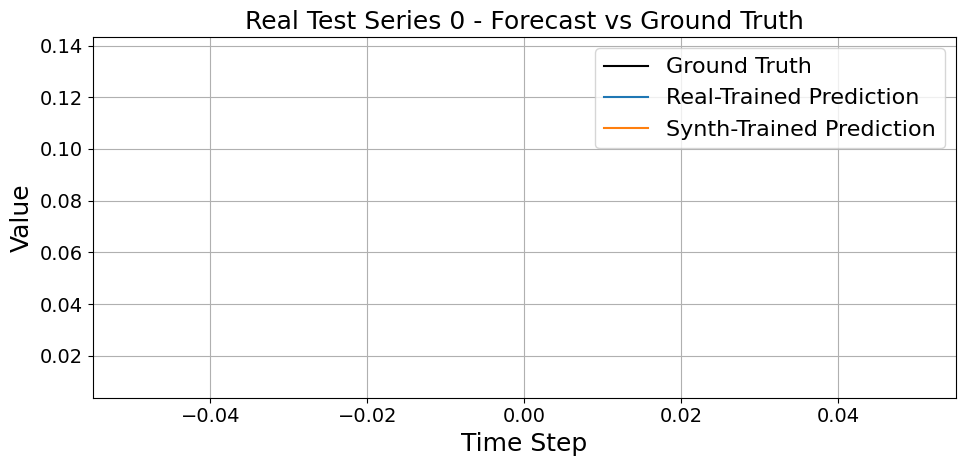

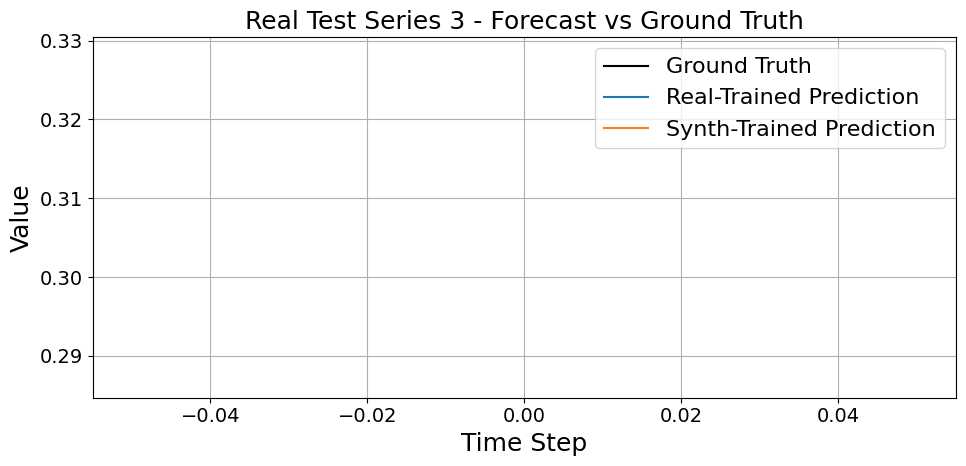

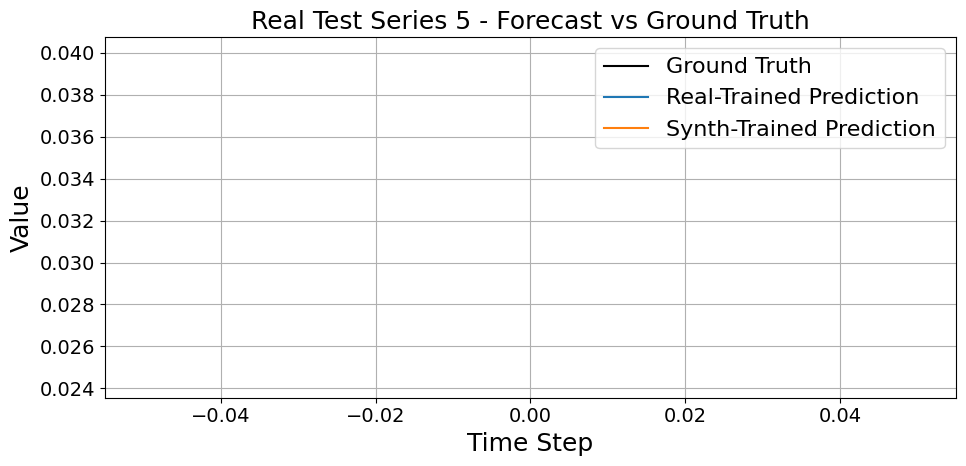

In [107]:
import matplotlib.pyplot as plt

def plot_predictions(models, real_test_data, n_lags=5, series_indices=[0, 1, 2]):
    for idx in series_indices:
        ts = real_test_data[idx, 0, :]
        df = create_lag_features(ts, n_lags)
        X = df.drop(columns=['y']).values
        y = df['y'].values

        plt.figure(figsize=(10, 5))
        plt.plot(range(len(y)), y, label="Ground Truth", color='black')

        for name, model in models.items():
            y_pred = model.predict(X)
            plt.plot(range(len(y)), y_pred, label=f"{name} Prediction")

        plt.title(f"Real Test Series {idx} - Forecast vs Ground Truth")
        plt.xlabel("Time Step")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(viz_dir, f"ts_{idx}_plot.png"))
        plt.show()

models = {
    "Real-Trained": real_model,
    "Synth-Trained": synth_model
}
plot_predictions(models, real_data_test, series_indices=[0, 3, 5], n_lags=6)

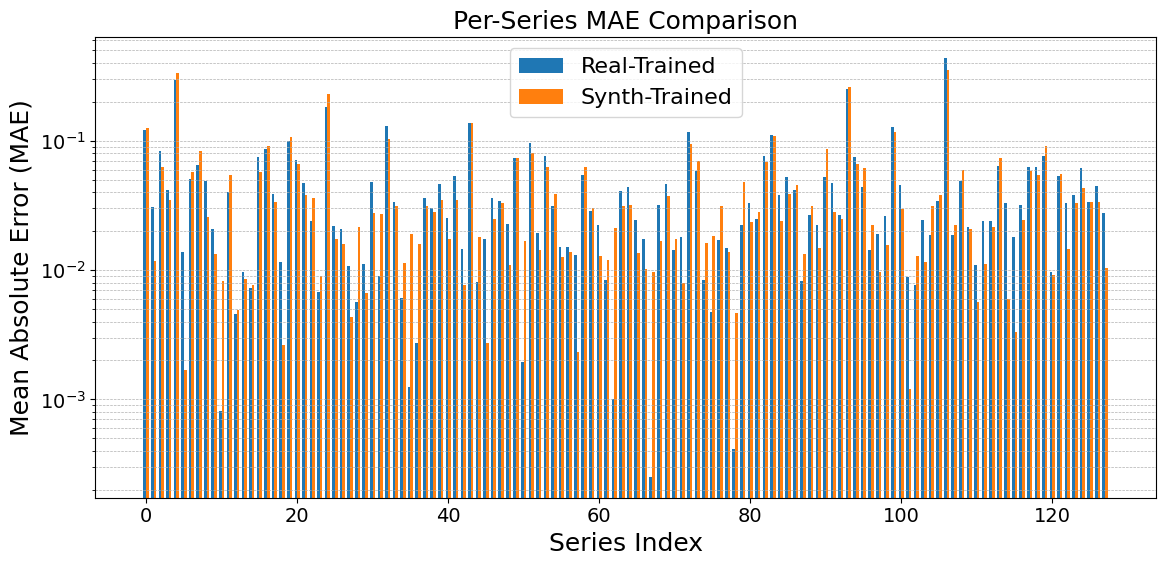

In [108]:
def per_series_mae(models, real_test_data, n_lags=5, log_scale=True):
    mae_dict = {name: [] for name in models}

    for i in range(real_test_data.shape[0]):
        ts = real_test_data[i, 0, :]
        df = create_lag_features(ts, n_lags)
        X = df.drop(columns=['y']).values
        y = df['y'].values

        for name, model in models.items():
            y_pred = model.predict(X)
            mae = np.mean(np.abs(y - y_pred))

            if not np.isfinite(mae) or mae <= 0:
                mae = 1e-6
            mae_dict[name].append(mae)

    x = np.arange(real_test_data.shape[0])
    width = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, mae_dict["Real-Trained"], width, label='Real-Trained')
    plt.bar(x + width/2, mae_dict["Synth-Trained"], width, label='Synth-Trained')
    plt.xlabel("Series Index")
    plt.ylabel("Mean Absolute Error (MAE)")
    plt.title("Per-Series MAE Comparison")

    if log_scale:
        plt.yscale("log")

    plt.legend()
    plt.tight_layout()
    plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
    plt.savefig(os.path.join(viz_dir, "mae_plot_log.png" if log_scale else "mae_plot.png"))
    plt.show()

per_series_mae(models, real_data_test, log_scale=True, n_lags=6)

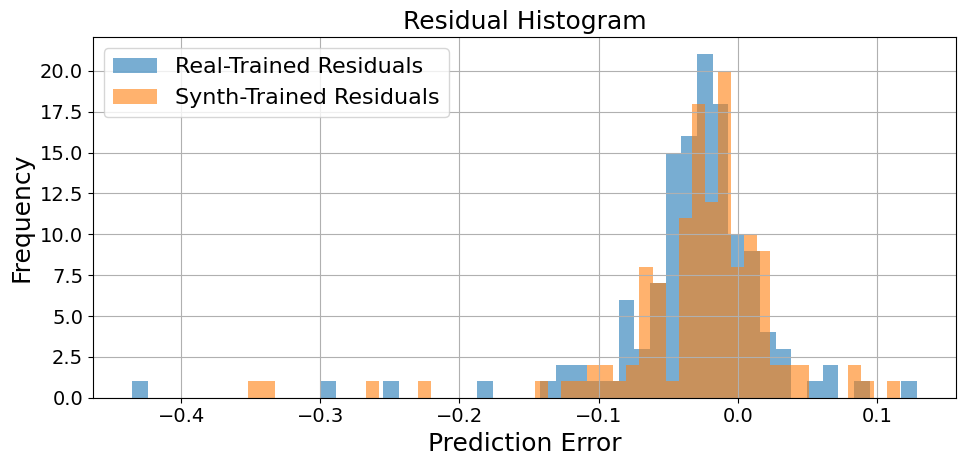

In [109]:
def plot_residual_histograms(models, X_test, y_test):
    plt.figure(figsize=(10, 5))

    for name, model in models.items():
        y_pred = model.predict(X_test)
        residuals = y_test - y_pred
        plt.hist(residuals, bins=50, alpha=0.6, label=f"{name} Residuals")

    plt.title("Residual Histogram")
    plt.xlabel("Prediction Error")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir, f"residual_plot.png"))
    plt.show()

plot_residual_histograms(models, X_real_test, y_real_test)

In [110]:
# from sklearn.metrics import mean_absolute_error
# def plot_residual_scatter(models, X_test, y_test, save_path="residual_scatter.png"):
#     # Predictions
#     y_pred_real = models["Real-Trained"].predict(X_test)
#     y_pred_synth = models["Synth-Trained"].predict(X_test)

#     # Residuals
#     residual_real = y_test - y_pred_real
#     residual_synth = y_test - y_pred_synth

#     # Scatter plot of residuals
#     plt.figure(figsize=(7, 7))
#     plt.scatter(residual_real, residual_synth, label='Test samples')

#     # Faded reference line (y = x)
#     min_val = min(residual_real.min(), residual_synth.min())
#     max_val = max(residual_real.max(), residual_synth.max())
#     plt.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.2)

#     # Grid and labels
#     plt.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
#     plt.axvline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)

#     plt.xlabel("Residuals (Real-trained model)")
#     plt.ylabel("Residuals (Synth-trained model)")
#     plt.title("Residual Scatter: Real vs. Synth Models")
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(save_path)
#     plt.show()

# plot_residual_scatter(models, X_real_test, y_real_test, save_path=os.path.join(viz_dir, "residual_scatter.png"))

C:\Users\Arne\AppData\Local\Temp\ipykernel_19492\794676808.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


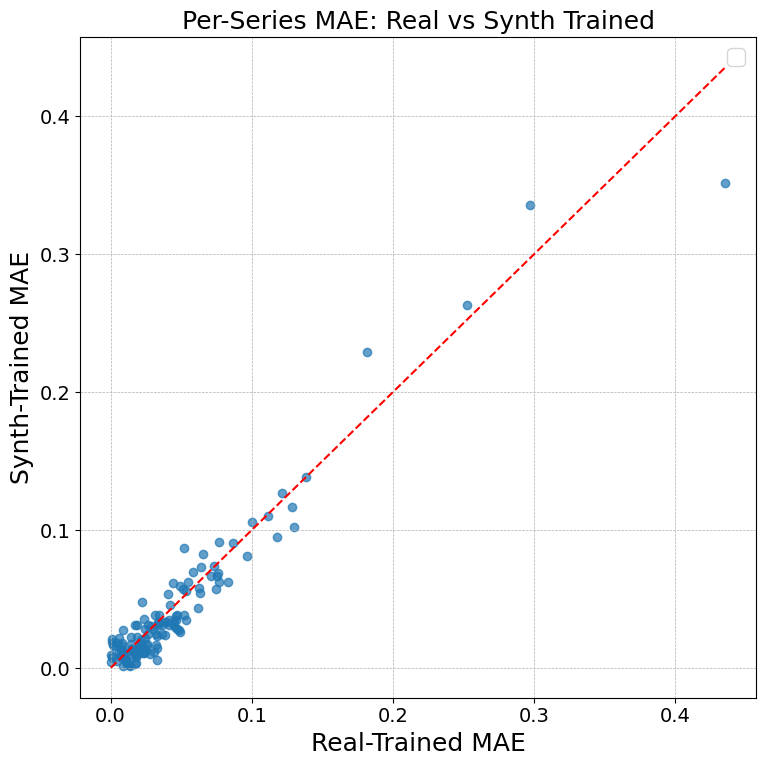

In [111]:
def per_series_mae_scatter(models, test_data, n_lags=5, log_scale=False, save_path="mae_scatter.png"):
    real_mae = []
    synth_mae = []

    for i in range(test_data.shape[0]):
        ts = test_data[i, 0, :]  # shape: (7,)
        df = create_lag_features(ts, n_lags=n_lags)

        X = df.drop(columns=["y"]).values  # shape: (T - n_lags, n_lags)
        y = df["y"].values

        y_pred_real = models["Real-Trained"].predict(X)
        y_pred_synth = models["Synth-Trained"].predict(X)

        mae_real = np.mean(np.abs(y - y_pred_real))
        mae_synth = np.mean(np.abs(y - y_pred_synth))

        real_mae.append(mae_real if mae_real > 0 else 1e-6)
        synth_mae.append(mae_synth if mae_synth > 0 else 1e-6)

    # Plot
    plt.figure(figsize=(8, 8))
    plt.scatter(real_mae, synth_mae, alpha=0.7)
    min_val, max_val = min(real_mae + synth_mae), max(real_mae + synth_mae)
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("Real-Trained MAE")
    plt.ylabel("Synth-Trained MAE")
    plt.title("Per-Series MAE: Real vs Synth Trained")

    if log_scale:
        plt.xscale("log")
        plt.yscale("log")

    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(viz_dir,save_path))
    plt.show()

per_series_mae_scatter(models, test_data=real_data_test, n_lags=6, log_scale=False)